In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import skew

In [2]:
%load_ext autoreload
%autoreload 2

RNG = np.random.default_rng(2024)
np.set_printoptions(suppress=True)

In [3]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

In [4]:
FONTSIZE_1 = 32
FONTSIZE_2 = 22

In [5]:
ev_diff = np.arange(-6, 6+1, 2)
num_trials = np.array([10, 10, 10, 80, 10, 10, 10])
ev_diff

array([-6, -4, -2,  0,  2,  4,  6])

## New Lotteries

In [6]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between -5 and 20
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 5:
                    # check if absolute var_diff is between 2 and 20
                    if np.abs(var_a - var_b) <= 10 and np.abs(var_a - var_b) >= 2:
                        # check if spread is larger for high variance option
                        # if (np.max(gamble_a) + np.abs(np.min(gamble_a))) < (np.max(gamble_b) + np.abs(np.min(gamble_b))):
                        # check for loss and var confound
                        if loss_a < loss_b and var_a < var_b:
                            gamble = [
                                {                            
                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                }
                            ]
                            gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                            counter += 1
                            if counter == num_trials[i]:
                                break
gamble_df.to_csv(f"../data/lotteries_new.csv", index=False)

  0%|          | 0/7 [00:00<?, ?it/s]/var/folders/9q/trrmd4jn4bx40rltjz_fmx4h0000gp/T/ipykernel_98182/1672564232.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
100%|██████████| 7/7 [28:59<00:00, 248.54s/it]


In [8]:
# plot = sns.scatterplot(data=gamble_df, x="ev_diff", y="loss_diff", color='maroon')
# plot.tick_params(axis='both', which='major', labelsize=FONTSIZE_2) 
# plt.xlabel('Expected Value Difference', fontsize=FONTSIZE_1, labelpad=10)
# plt.ylabel('Loss Difference', fontsize=FONTSIZE_1, labelpad=10)
# sns.despine()
# plt.savefig("../plots/ev_loss_diff.pdf", dpi=300, bbox_inches="tight")

## Old Lotteries

In [9]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between -5 and 20
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 5:
                    # check if absolute var_diff is between 2 and 20
                    if np.abs(var_a - var_b) <= 10 and np.abs(var_a - var_b) >= 2:
                        # check if spread is larger for high variance option
                        # if (np.max(gamble_a) + np.abs(np.min(gamble_a))) < (np.max(gamble_b) + np.abs(np.min(gamble_b))):
                        # check for loss and var confound
                        if loss_a < loss_b and var_a > var_b:
                            gamble = [
                                {                            
                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                }
                            ]
                            gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                            counter += 1
                            if counter == num_trials[i]:
                                break
gamble_df.to_csv(f"../data/lotteries_old.csv", index=False)

  0%|          | 0/7 [00:00<?, ?it/s]/var/folders/9q/trrmd4jn4bx40rltjz_fmx4h0000gp/T/ipykernel_98182/2105511125.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
100%|██████████| 7/7 [01:53<00:00, 16.28s/it]


## Lotteries Inspection

In [21]:
lotteries_new = pd.read_csv("../data/lotteries_new.csv")
lotteries_old = pd.read_csv("../data/lotteries_old.csv")

context_new = lotteries_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = lotteries_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

In [23]:
# Convert each row to a tuple
rows_as_tuples = [tuple(row) for row in context_new]

# Check if all rows are unique
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))

print("All rows are unique:", all_unique)

All rows are unique: True


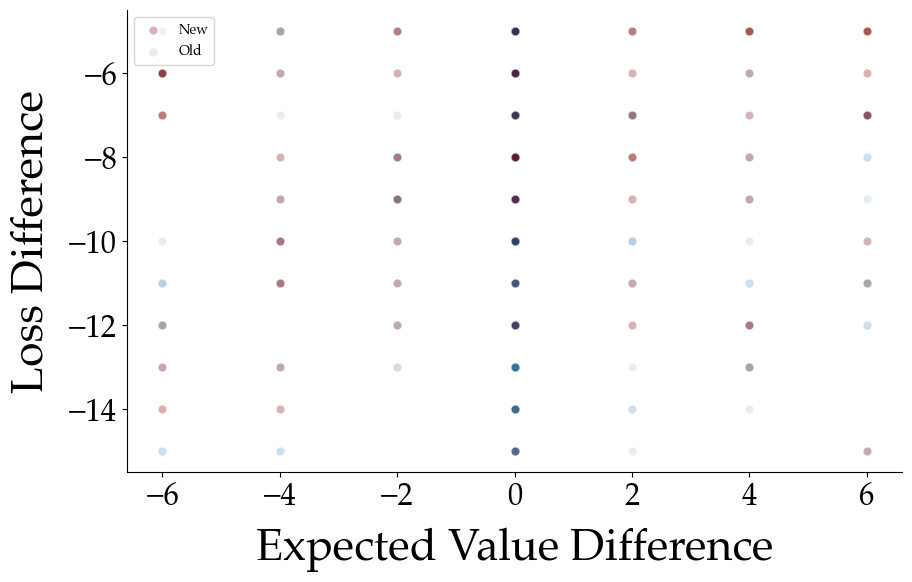

In [38]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=lotteries_new, x="ev_diff", y="loss_diff", color='maroon', label='New', alpha=0.3, ax=ax)
sns.scatterplot(data=lotteries_old, x="ev_diff", y="loss_diff", color='#005F99', label='Old', alpha=0.1, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Expected Value Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Loss Difference', fontsize=FONTSIZE_1, labelpad=10)
# ax.set_ylim(-20, 0)
sns.despine(ax=ax)

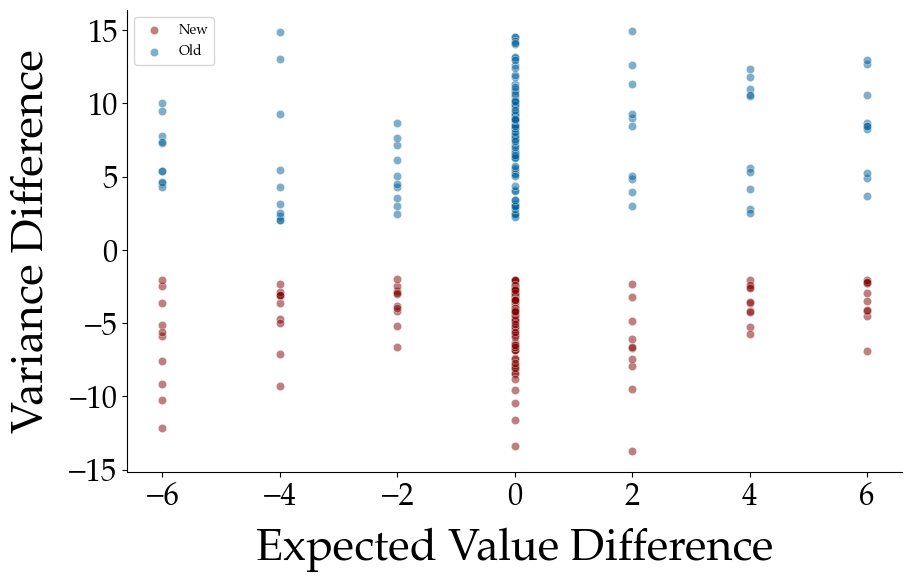

In [35]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=lotteries_new, x="ev_diff", y="var_diff", color='maroon', label='New', alpha=0.5, ax=ax)
sns.scatterplot(data=lotteries_old, x="ev_diff", y="var_diff", color='#005F99', label='Old', alpha=0.5, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Expected Value Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Variance Difference', fontsize=FONTSIZE_1, labelpad=10)
# ax.set_ylim(-20, 0)
sns.despine(ax=ax)

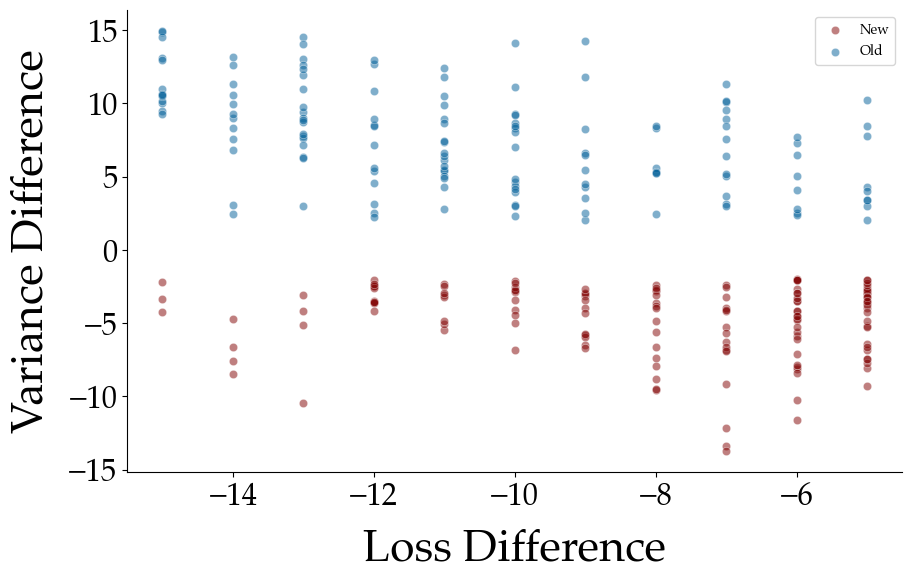

In [34]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=lotteries_new, x="loss_diff", y="var_diff", color='maroon', label='New', alpha=0.5, ax=ax)
sns.scatterplot(data=lotteries_old, x="loss_diff", y="var_diff", color='#005F99', label='Old', alpha=0.5, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Loss Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Variance Difference', fontsize=FONTSIZE_1, labelpad=10)
# ax.set_ylim(-20, 0)
sns.despine(ax=ax)

<Axes: xlabel='ev_a', ylabel='Count'>

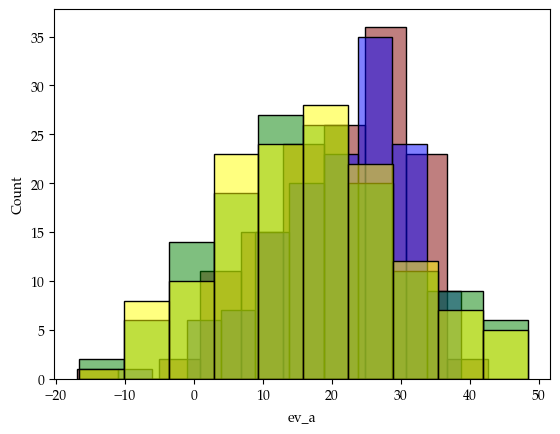

In [31]:
sns.histplot(data=lotteries_new, x="ev_a", color='maroon', alpha=0.5)
sns.histplot(data=lotteries_new, x="ev_b", color='blue', alpha=0.5)

sns.histplot(data=lotteries_old, x="ev_a", color='green', alpha=0.5)
sns.histplot(data=lotteries_old, x="ev_b", color='yellow', alpha=0.5)